Nama : Rangga Saputra

NIM : 250401020034

Kelas : IF405

---

# Praktikum Pertemuan 9: Algoritma Klasifikasi (Bagian 1)

## Langkah 1: Load Dataset & EDA Singkat

In [7]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = malignant, 1 = benign

print('Shape:', X.shape)
print('Distribusi target:')
print(pd.Series(y).value_counts(normalize=True).round(3))

Shape: (569, 30)
Distribusi target:
1    0.627
0    0.373
Name: proportion, dtype: float64


**Note:** Dataset terdiri dari 569 observasi dengan 30 fitur numerik. Distribusi target menunjukkan sekitar 62.7% kasus *Benign* (jinak, kelas 1) dan 37.3% kasus *Malignant* (ganas, kelas 0).

## Langkah 2: Preprocessing (Train-Test Split & Scaling)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)

X_train: (455, 30) | X_test: (114, 30)


## Langkah 3: Latih Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)

coef_df = pd.DataFrame({'Fitur': X.columns,
                        'Koefisien': log_model.coef_[0]
                       }).sort_values('Koefisien', key=abs, ascending=False)
print(coef_df.head())

                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


**Note:** Kelima fitur dengan koefisien absolut terbesar semuanya bernilai **negatif**, artinya semakin besar nilai fitur tersebut (misalnya `worst texture` atau `worst radius`, yang menunjukkan sel berukuran besar dan tidak beraturan), semakin rendah probabilitas kelas 1 (Benign), semakin mengarah ke Malignant. Hal ini konsisten dengan intuisi medis: sel kanker cenderung berukuran lebih besar dan teksturnya lebih tidak homogen dibanding sel jinak.

## Langkah 4: Latih Decision Tree

In [10]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

imp_df = pd.DataFrame({'Fitur': X.columns,
                       'Importance': tree_model.feature_importances_
                      }).sort_values('Importance', ascending=False)
print(imp_df.head())

                   Fitur  Importance
20          worst radius    0.733548
27  worst concave points    0.122028
11         texture error    0.045785
21         worst texture    0.032319
26       worst concavity    0.017161


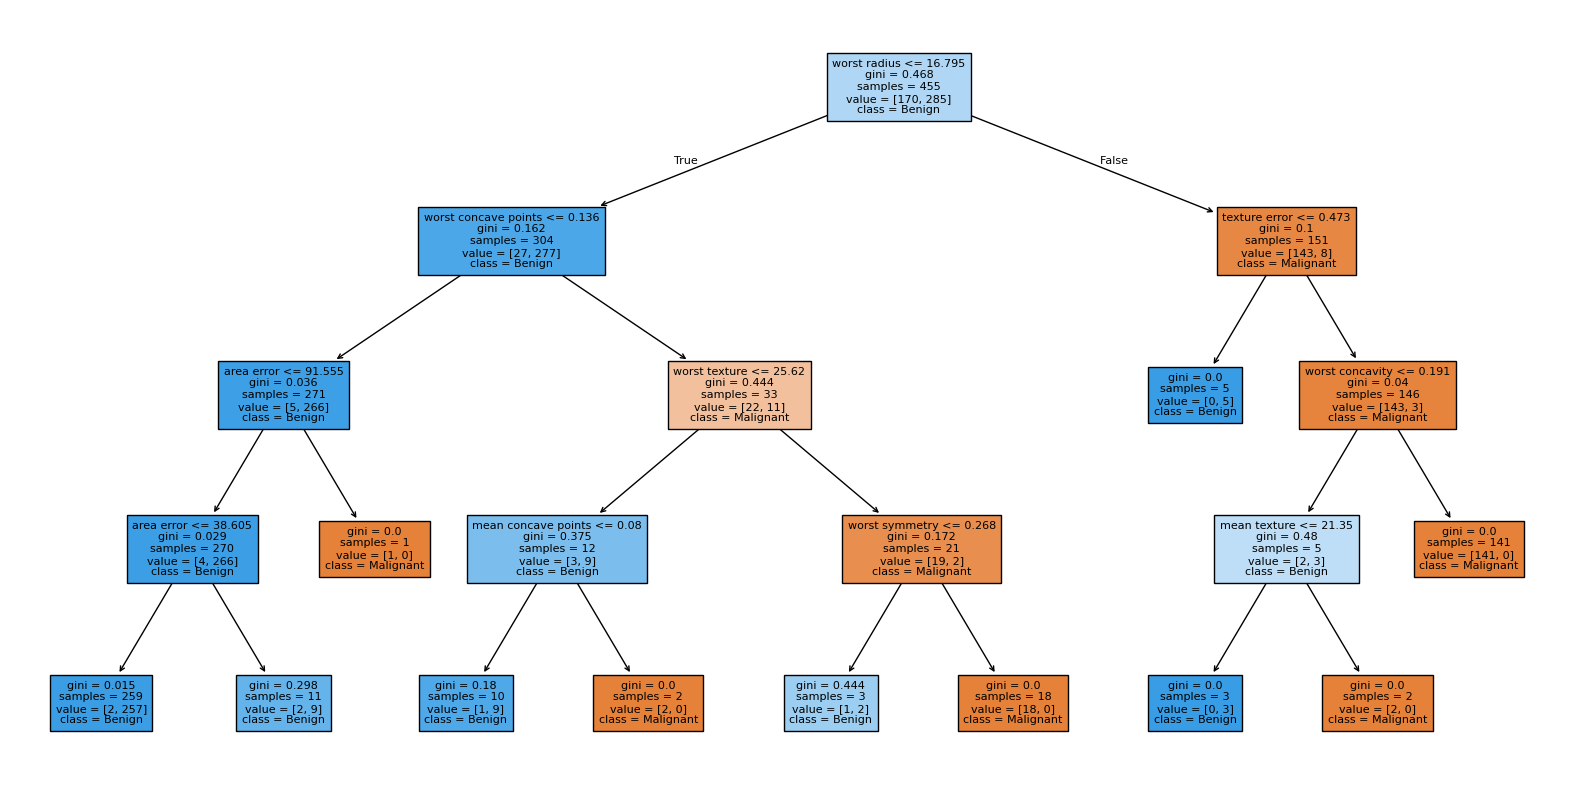

In [11]:
plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=X.columns,
          class_names=['Malignant','Benign'], filled=True, fontsize=8)
plt.show()

**Note:** Fitur `worst radius` mendominasi keputusan splitting pertama pada pohon, diikuti oleh `worst concave points`. Ini sejalan dengan hasil Logistic Regression yang juga menempatkan fitur-fitur "worst" (nilai ekstrem sel) sebagai prediktor utama.

## Langkah 5: Evaluasi & Bandingkan Kedua Model

In [12]:
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

for name, y_pred in [('Logistic Regression', y_pred_log), ('Decision Tree', y_pred_tree)]:
    print(f"\n=== {name} ===")
    print(confusion_matrix(y_test, y_pred))
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
    print(f"F1-Score : {f1_score(y_test, y_pred):.3f}")


=== Logistic Regression ===
[[41  1]
 [ 1 71]]
Accuracy : 0.982
Precision: 0.986
Recall   : 0.986
F1-Score : 0.986

=== Decision Tree ===
[[39  3]
 [ 4 68]]
Accuracy : 0.939
Precision: 0.958
Recall   : 0.944
F1-Score : 0.951


## Kesimpulan Perbandingan Logistic Regression vs Decision Tree

**Model mana yang Recall-nya lebih tinggi?**

Logistic Regression punya Recall 0.986, lebih tinggi dari Decision Tree yang 0.944. Artinya Logistic Regression lebih sedikit melewatkan kasus positif dibanding Decision Tree.

**Kenapa Recall lebih penting daripada Accuracy untuk diagnosis kanker?**

Karena kalau memakai Accuracy saja, kesalahan model tidak dibedakan jenisnya. Padahal dalam diagnosis kanker, False Negative (pasien sakit tapi diprediksi sehat) jauh lebih berbahaya daripada False Positive (pasien sehat disuruh cek ulang). Recall fokus mengukur seberapa banyak kasus positif asli yang berhasil terdeteksi, jadi lebih relevan untuk meminimalkan risiko kanker yang terlewat.

**Perbedaan performa**

Selisihnya cuma sekitar 3–5%, tergolong kecil, apalagi data test-nya hanya 114 sampel jadi 1 kesalahan saja sudah mengubah persentase cukup besar. Tapi Logistic Regression tetap unggul di semua metrik (Accuracy, Precision, Recall, F1), jadi lebih disarankan untuk kasus ini, sementara Decision Tree tetap berguna karena lebih mudah dijelaskan secara visual.